My Portfolio 1 exercises submission - Obashola Obisesan (B00868372).

a. Is answered below

In [7]:
# All necessary packages imported at the start for good practice 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
df = pd.read_csv('week4data.csv')

b. Initial plotting of the data.

I believe the relationship is Polynomial Regression and or Polynomial relationship.

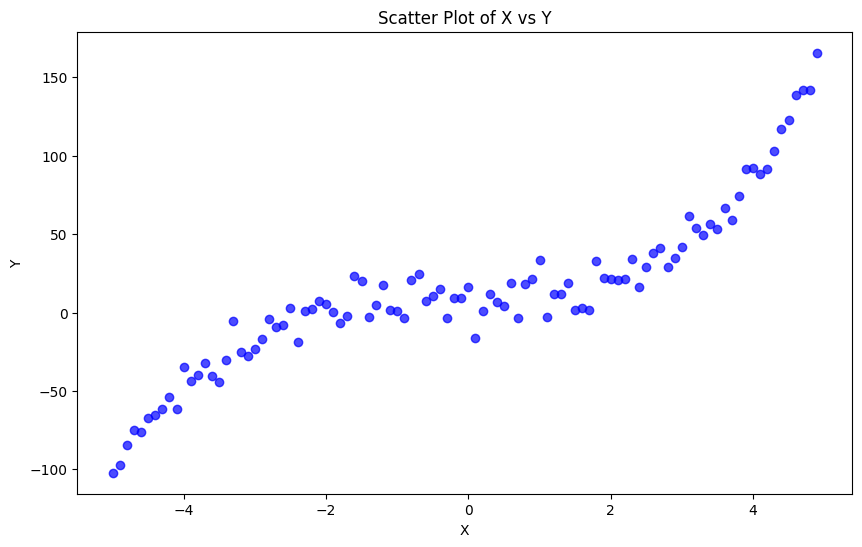

In [8]:
plt.figure(figsize=(10,6))
plt.scatter(df["X"], df["y"], color="blue", alpha=0.7) # access the columns in the dataframe
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Scatter Plot of X vs Y")
plt.show()


c. Splitting the data into sections used for training and testing.

In [ ]:
X = df[['X']] # as defined in the column, forced to 2D array to stop val errors
y = df['y']

train_X, val_X, train_y, val_y = train_test_split(X, y, test_size=0.2, random_state = 0) # test_size = 0.2 means 80% of the data is used for training the model

d. Transformation of the training data using a polynomial, followed by calculations of coefficients and the intercept.

In [10]:
# Firstly, the degree of the polynomial is set to 3 as linear regression is a 1st degree polynomial and parabolas are 2nd degree, this graph looks like an S (3rd degree)
poly = PolynomialFeatures(degree=3, include_bias=False) # do not assume the intercept is 0

poly_features = poly.fit_transform(train_X) # polynomial of the features (x vals) 
# with fit() I declare I want to transform the training data before transforming it with transform(), fit_transform() combines the 2 methods
# since the degree of a polynomial is the highest power/exponent I needed values from x^0 to x^3 and fit_transform() created all the necessary x values for the train_X and my set degree

# creation of polynomial regression model
poly_reg_model = LinearRegression() # polynomial regression is a linear model
poly_reg_model.fit(poly_features, train_y)

# The intercept (theta_0)
print(f"Intercept (theta_0): {poly_reg_model.intercept_}")

# The coefficients (theta_1, theta_2, theta_3) for X, X^2, and X^3 or theta_n for x_n
print(f"Coefficients (theta_1, theta_2 and theta_3): {poly_reg_model.coef_}")

Intercept (theta_0): 7.614990473632592
Coefficients (theta_1, theta_2 and theta_3): [-0.09421522  0.88086798  1.07578016]


e. Plotting training data and generating the line of best fit with the calculated intercept and coefficients.

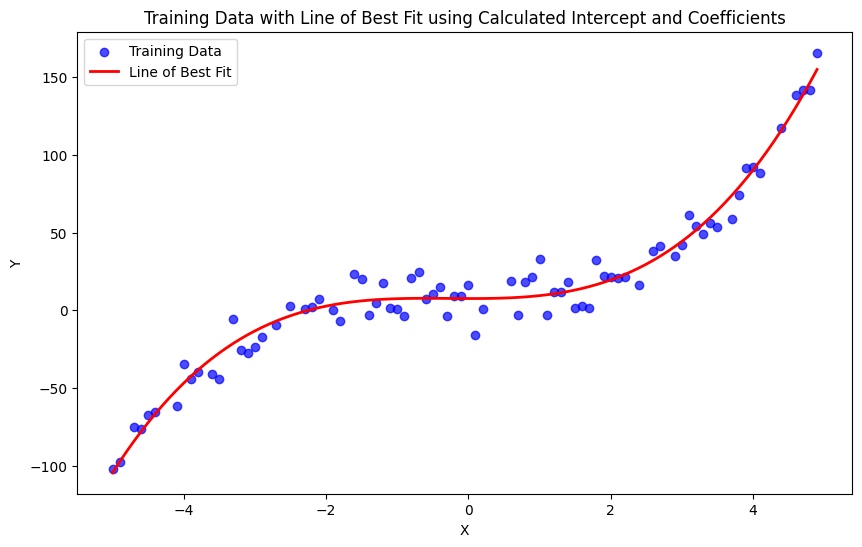

In [11]:
# Scatter plot of the training data
plt.figure(figsize=(10,6))
plt.scatter(train_X, train_y, color='blue', alpha=0.7, label='Training Data')

# create a 100 points between min and max for curve smoothness, find the min and max values of the data to limit the range of plots
# reshape(1, -1) to turn it into a 2D array 
X_fit = np.linspace(train_X.min(), train_X.max(), 100).reshape(-1, 1)

X_fit_poly = poly.fit_transform(X_fit)

# Calculate predicted y values for the line of best fit's x values using the calculated intercept and coefficients (predict uses the already stored coeffs and intercept)
y_fit = poly_reg_model.predict(X_fit_poly)

# Plot the line of best fit using intercept and coefficients
plt.plot(X_fit, y_fit, color='red', linewidth=2, label='Line of Best Fit')

# Add labels, title, legend
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Training Data with Line of Best Fit using Calculated Intercept and Coefficients')
plt.legend() # legend in the top left describing the graph iconography/symbols (scatter points and line of best fit)
plt.show()


f. MAE, MSE and R2 calculated using the test/val data then displayed.

In [12]:
# Transform the validation data for consistency as I have already transformed the training data
X_test_poly = poly.fit_transform(val_X)

# Predict Y-values for the Test Data
y_pred2 = poly_reg_model.predict(X_test_poly)

# Calculate the metrics
# No x values as these are the differences between the actual dependent variables values and predicted values (the difference between y and y hat)
mae = mean_absolute_error(val_y, y_pred2)
mse = mean_squared_error(val_y, y_pred2)
r2 = r2_score(val_y, y_pred2)

print("The mean absolute error is: ", mae)
print("The mean squared error is: ", mse)
print("The mean R2 score is: ", r2)


The mean absolute error is:  4.887490432469666
The mean squared error is:  40.330923731481
The mean R2 score is:  0.9855043768368271


g. The calculated R2 score indicates that the regression model I have generated is highly accurate as it is less than 0.1/a tenth away from the ideal R2 score of 1, this means the model almost perfectly fits the data and the predicted values are not far off from the actual values.

Sources I consulted:

Initial plotting of data
|||||||||||||||||
https://realpython.com/visualizing-python-plt-scatter/
https://realpython.com/pandas-plot-python/
https://pandas.pydata.org/docs/user_guide/visualization.html
https://www.geeksforgeeks.org/data-analysis/how-to-set-dataframe-column-value-as-x-axis-labels-in-python-pandas/
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html
https://blog.qasource.com/software-development-and-qa-tips/how-to-add-transparent-layer-to-matplotlib-plot#:~:text=In%20Matplotlib%2C%20plot%20elements'%20transparency,Completely%20opaque%20(fully%20visible).
https://www.freecodecamp.org/news/matplotlib-figure-size-change-plot-size-in-python/
https://en.wikipedia.org/wiki/Polynomial_regression

Train test split
|||||||
https://realpython.com/train-test-split-python-data/


Transform training data using a polynomial
|||||
https://data36.com/polynomial-regression-python-scikit-learn/
https://www.activestate.com/resources/quick-reads/how-to-convert-pandas-to-numpy/#:~:text=It%20is%20quite%20easy%20to,Pandas%20will%20do%20the%20trick.&text=This%20will%20return%20us%20a,with%20the%20column%20names%20discarded.
https://www.w3schools.com/python/pandas/pandas_dataframes.asp
Find intercept and coefficents:
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

Plotting training data and generating the line of best fit with the calculated intercept and coefficients.
|||||||
https://www.w3schools.com/python/python_ml_polynomial_regression.asp
https://en.wikipedia.org/wiki/Polynomial_regression
https://www.geeksforgeeks.org/python/matplotlib-pyplot-legend-in-python/

e.
|||||
https://www.geeksforgeeks.org/python/how-to-calculate-mean-absolute-error-in-python/
https://www.geeksforgeeks.org/python/python-mean-squared-error/
https://www.geeksforgeeks.org/machine-learning/python-coefficient-of-determination-r2-score/

g.
https://www.geeksforgeeks.org/machine-learning/ml-r-squared-in-regression-analysis/


Misc:

ML4DA lectures and lecture materials

Kaggle's Intro to ML course

<img src="C:\Users\Oba\OneDrive - University of the West of Scotland\Y4 Stuff\Machine Learning for Data Analytics\GraNotes1.jpg" alt="PicOfWhiteboard" />
